# Week 7 - Advanced Models

This notebook tests advanced tree-based boosting models after the Week 6 feature engineering work.

The evaluation follows the team-standard time split:

- Modeling data: closed sales from 2025-06 through 2026-05
- Training set: 2025-06 through 2026-04
- Test set: 2026-05

The main advanced model is XGBoost. I use light hyperparameter tuning across max depth, learning rate, and number of trees, then evaluate the best versions on the unchanged May 2026 test month.

## Week 7 Goal

The goal for Week 7 is to test whether a stronger model family can improve price prediction while keeping the evaluation methodology consistent.

The earlier raw-price XGBoost attempt produced unstable predictions on the long-tailed housing-price data. This version uses a more realistic setup:

- XGBoost predicts `log(ClosePrice)` and converts predictions back to dollars for evaluation.
- Several feature sets are tested, from the original baseline features to richer market-context features.
- A validation month is used for light tuning before final evaluation on the unchanged May 2026 test month.
- Final results use the same metrics as earlier weeks: `R²`, `MAPE`, `MdAPE`, `MAE`, and `RMSE`.

The main question is whether XGBoost can keep a similar `R²` while reducing percentage error for typical homes.

In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "XGBoost is not installed. Run `pip install xgboost` in the same environment as this notebook, then rerun this cell."
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
output_dir = Path("../outputs")
engineered_path = output_dir / "week6_feature_engineered_dataset.csv"
base_path = output_dir / "full_preprocessed_week3.csv"

print(f"Engineered dataset path: {engineered_path}")
print(f"Base dataset path: {base_path}")

Engineered dataset path: ../outputs/week6_feature_engineered_dataset.csv
Base dataset path: ../outputs/full_preprocessed_week3.csv


## Load Data

This notebook prefers the Week 6 enriched dataset because it already contains the engineered features and school district mapping. If that file is not available, it falls back to the Week 3 preprocessed dataset and recreates the core engineered features.

In [4]:
data_path = engineered_path
if not data_path.exists():
    data_path = base_path

print(f"Using data file: {data_path.name}")
df = pd.read_csv(data_path)

# Keep the time split fixed so results are comparable with the rest of the team.
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["close_month"] = pd.to_datetime(df["close_month"])

modeling_start = pd.Timestamp("2025-06-01")
modeling_end = pd.Timestamp("2026-05-01")
test_month = pd.Timestamp("2026-05-01")
train_months = pd.period_range("2025-06", "2026-04", freq="M").to_timestamp()
expected_months = pd.period_range("2025-06", "2026-05", freq="M").to_timestamp()

df = df.loc[
    (df["close_month"] >= modeling_start) & (df["close_month"] <= modeling_end)
].copy()
available_months = sorted(df["close_month"].dropna().unique())
missing_months = [
    m.strftime("%Y-%m")
    for m in expected_months
    if m not in set(pd.to_datetime(available_months))
]
if missing_months:
    raise ValueError(
        "Missing required modeling months: "
        + ", ".join(missing_months)
        + ". Rerun 02_preprocessing and 05_feature_engineering after updating the 12-month data window."
    )

train_df = df[df["close_month"].isin(train_months)].copy()
test_df = df[df["close_month"] == test_month].copy()

print(f"Rows: {len(df):,}")
print(f"Train months: {[pd.Timestamp(m).strftime('%Y-%m') for m in train_months]}")
print(f"Test month: {test_month.strftime('%Y-%m')}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")

df.head()

Using data file: week6_feature_engineered_dataset.csv
Rows: 130,313
Train months: ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: 2026-05
Train rows: 118,292
Test rows: 12,021


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish,list_price_per_sqft,lot_to_living_ratio,is_newer_home,high_bedroom_flag,bedrooms_per_1000_sqft,log_lot_size,log_days_on_market,living_area_per_bedroom,unified_district_name,is_unknown_district
0,890000.0000,2025-06-13,2025-06-01,889000.0000,3000.0000,3.0000,3.0000,9600.0000,2021.0000,34.2647,-117.2210,181.0000,4.0000,8.0067,1.0000,San Bernardino,296.3333,3.2000,1,0,1.0000,9.1696,5.2040,1000.0000,Rim of the World Unified,0
1,1876384.0000,2025-06-30,2025-06-01,1899999.0000,1800.0000,3.0000,3.0000,10400.0000,1963.0000,34.1080,-118.3903,87.0000,62.0000,7.4961,1.0000,Los Angeles,1055.5550,5.7778,0,0,1.6667,9.2497,4.4773,600.0000,Los Angeles Unified,0
2,4820000.0000,2025-06-30,2025-06-01,4820000.0000,4270.0000,6.0000,6.0000,22505.0000,1980.0000,37.5674,-122.3882,0.0000,45.0000,8.3596,1.0000,San Mateo,1128.8056,5.2705,0,1,1.4052,10.0215,0.0000,711.6667,Unknown_District,1
3,865000.0000,2025-06-30,2025-06-01,865000.0000,1442.0000,3.0000,2.0000,4800.0000,1985.0000,33.9061,-117.7778,0.0000,40.0000,7.2745,0.6667,Orange,599.8613,3.3287,0,0,2.0804,8.4766,0.0000,480.6667,Placentia-Yorba Linda Unified,0
4,875000.0000,2025-06-30,2025-06-01,875000.0000,1086.0000,3.0000,1.0000,5500.0000,1953.0000,37.7059,-122.0594,0.0000,72.0000,6.9912,0.3333,Alameda,805.7090,5.0645,0,0,2.7624,8.6127,0.0000,362.0000,Castro Valley Unified,0


## Feature Strategy

This model tries to represent real housing-price drivers more directly:

- Property size and room structure: living area, lot size, bedrooms, bathrooms
- Age and timing: year built, property age, days on market
- Listing signal: list price and list price per square foot
- Location: county and unified school district
- Historical market context: county and district-level median sale price from the training period only

The historical market features are calculated from the training period and then mapped onto validation or test rows. This keeps the test month unseen.

In [5]:
target_col = "ClosePrice"

baseline_features = [
    "ListPrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "DaysOnMarket",
    "property_age",
    "log_living_area",
    "bathrooms_per_bedroom",
    "CountyOrParish",
]

reality_features = baseline_features + [
    "list_price_per_sqft",
    "lot_to_living_ratio",
    "is_newer_home",
    "high_bedroom_flag",
    "bedrooms_per_1000_sqft",
    "log_lot_size",
    "log_days_on_market",
    "living_area_per_bedroom",
    "is_unknown_district",
    "unified_district_name",
]

market_context_features = reality_features + [
    "county_hist_median_closeprice",
    "county_hist_median_list_ppsf",
    "county_hist_transaction_count",
    "district_hist_median_closeprice",
    "district_hist_transaction_count",
]

for feature_list_name, feature_list in {
    "baseline_features": baseline_features,
    "reality_features": reality_features,
}.items():
    missing_cols = [col for col in feature_list if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{feature_list_name} is missing columns: {missing_cols}")

print(f"Baseline feature count: {len(baseline_features)}")
print(f"Reality feature count: {len(reality_features)}")
print(f"Market context feature count: {len(market_context_features)}")

Baseline feature count: 13
Reality feature count: 23
Market context feature count: 28


## Validation Split

For tuning, the most recent training month is used as validation. The final test month remains untouched until final evaluation.

In [6]:
validation_month = sorted(train_df["close_month"].dropna().unique())[-1]
tuning_train_df = train_df[train_df["close_month"] < validation_month].copy()
validation_df = train_df[train_df["close_month"] == validation_month].copy()

print(
    f"Tuning train months: {sorted(tuning_train_df['close_month'].dt.strftime('%Y-%m').unique())}"
)
print(f"Validation month: {pd.Timestamp(validation_month).strftime('%Y-%m')}")
print(f"Tuning train rows: {len(tuning_train_df):,}")
print(f"Validation rows: {len(validation_df):,}")

Tuning train months: ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
Validation month: 2026-04
Tuning train rows: 106,258
Validation rows: 12,034


## Helper Functions

These functions keep preprocessing, market-context feature creation, log-target modeling, and metrics consistent across experiments.

In [7]:
def evaluate_predictions(y_true, preds):
    y_true_series = pd.Series(y_true).reset_index(drop=True)
    pred_series = pd.Series(preds).reset_index(drop=True)
    ape = (y_true_series - pred_series).abs() / y_true_series
    return {
        "MAE": mean_absolute_error(y_true_series, pred_series),
        "RMSE": np.sqrt(mean_squared_error(y_true_series, pred_series)),
        "R2": r2_score(y_true_series, pred_series),
        "MAPE": ape.mean(),
        "MdAPE": ape.median(),
    }


def add_market_context(fit_df, apply_df):
    fit_df = fit_df.copy()
    apply_df = apply_df.copy()
    fit_df["fit_list_ppsf"] = fit_df["ListPrice"] / fit_df["LivingArea"].replace(
        0, np.nan
    )

    global_median_close = fit_df["ClosePrice"].median()
    global_median_ppsf = fit_df["fit_list_ppsf"].median()

    county_stats = fit_df.groupby("CountyOrParish").agg(
        county_hist_median_closeprice=("ClosePrice", "median"),
        county_hist_median_list_ppsf=("fit_list_ppsf", "median"),
        county_hist_transaction_count=("ClosePrice", "size"),
    )

    district_stats = fit_df.groupby("unified_district_name").agg(
        district_hist_median_closeprice=("ClosePrice", "median"),
        district_hist_transaction_count=("ClosePrice", "size"),
    )

    apply_df = apply_df.merge(county_stats, on="CountyOrParish", how="left")
    apply_df = apply_df.merge(district_stats, on="unified_district_name", how="left")

    apply_df["county_hist_median_closeprice"] = apply_df[
        "county_hist_median_closeprice"
    ].fillna(global_median_close)
    apply_df["county_hist_median_list_ppsf"] = apply_df[
        "county_hist_median_list_ppsf"
    ].fillna(global_median_ppsf)
    apply_df["county_hist_transaction_count"] = apply_df[
        "county_hist_transaction_count"
    ].fillna(0)
    apply_df["district_hist_median_closeprice"] = apply_df[
        "district_hist_median_closeprice"
    ].fillna(global_median_close)
    apply_df["district_hist_transaction_count"] = apply_df[
        "district_hist_transaction_count"
    ].fillna(0)
    return apply_df


def make_preprocessor(feature_cols, fit_frame, scale_numeric=False):
    numeric_features = (
        fit_frame[feature_cols].select_dtypes(include=["number"]).columns.tolist()
    )
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )


def build_linear_model(feature_cols, fit_frame):
    return Pipeline(
        steps=[
            (
                "preprocess",
                make_preprocessor(feature_cols, fit_frame, scale_numeric=True),
            ),
            ("model", LinearRegression()),
        ]
    )


def build_xgb_model(
    feature_cols, fit_frame, max_depth, learning_rate, n_estimators, min_child_weight
):
    xgb = XGBRegressor(
        objective="reg:squarederror",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        min_child_weight=min_child_weight,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=8.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )

    return Pipeline(
        steps=[
            (
                "preprocess",
                make_preprocessor(feature_cols, fit_frame, scale_numeric=False),
            ),
            ("model", xgb),
        ]
    )


def prepare_experiment_frames(train_source_df, eval_source_df, feature_set_name):
    if feature_set_name == "baseline":
        feature_cols = baseline_features
        train_ready = train_source_df.copy()
        eval_ready = eval_source_df.copy()
    elif feature_set_name == "reality":
        feature_cols = reality_features
        train_ready = train_source_df.copy()
        eval_ready = eval_source_df.copy()
    elif feature_set_name == "market_context":
        feature_cols = market_context_features
        train_ready = add_market_context(train_source_df, train_source_df)
        eval_ready = add_market_context(train_source_df, eval_source_df)
    else:
        raise ValueError(f"Unknown feature set: {feature_set_name}")
    return train_ready, eval_ready, feature_cols


def train_predict_xgb_log(train_ready, eval_ready, feature_cols, params):
    model = build_xgb_model(feature_cols, train_ready, **params)
    model.fit(train_ready[feature_cols], np.log1p(train_ready[target_col]))
    log_preds = model.predict(eval_ready[feature_cols])
    preds = np.expm1(log_preds)
    preds = np.clip(preds, 0, None)
    return model, preds


## Linear Regression Reference

The advanced models are compared against the retained linear-regression baseline from earlier weeks.

In [8]:
linear_model = build_linear_model(baseline_features, train_df)
linear_model.fit(train_df[baseline_features], train_df[target_col])
linear_test_preds = linear_model.predict(test_df[baseline_features])
linear_metrics = evaluate_predictions(test_df[target_col], linear_test_preds)

display(pd.DataFrame([{"model_name": "LinearRegression", **linear_metrics}]))

,model_name,MAE,RMSE,R2,MAPE,MdAPE
0,LinearRegression,198948.9216,1014590.5986,0.6336,0.2456,0.1014


## XGBoost Experiments And Light Tuning

This section tests several realistic XGBoost setups. Each setup gets a small tuning grid, and the best version is selected using validation `MAPE`, `MdAPE`, prediction sanity checks, and `R2`.

In [9]:
param_grid = [
    {
        "max_depth": 2,
        "learning_rate": 0.03,
        "n_estimators": 500,
        "min_child_weight": 10,
    },
    {
        "max_depth": 2,
        "learning_rate": 0.05,
        "n_estimators": 400,
        "min_child_weight": 10,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.03,
        "n_estimators": 600,
        "min_child_weight": 15,
    },
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "n_estimators": 450,
        "min_child_weight": 25,
    },
]

experiment_specs = [
    {
        "experiment_name": "xgb_log_baseline_all",
        "feature_set": "baseline",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_reality_all",
        "feature_set": "reality",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_market_context_all",
        "feature_set": "market_context",
        "filter_train": False,
    },
    {
        "experiment_name": "xgb_log_market_context_filtered",
        "feature_set": "market_context",
        "filter_train": True,
    },
]


def apply_training_filter(frame):
    return frame.loc[
        (frame["ClosePrice"] >= 100000)
        & (frame["ClosePrice"] <= 20000000)
        & (frame["LivingArea"] >= 400)
    ].copy()


tuning_rows = []

for spec in experiment_specs:
    base_tune_train = tuning_train_df.copy()
    if spec["filter_train"]:
        base_tune_train = apply_training_filter(base_tune_train)

    tune_train_ready, valid_ready, feature_cols = prepare_experiment_frames(
        base_tune_train, validation_df, spec["feature_set"]
    )

    for params in param_grid:
        model, valid_preds = train_predict_xgb_log(
            tune_train_ready, valid_ready, feature_cols, params
        )
        metrics = evaluate_predictions(valid_ready[target_col], valid_preds)
        sanity_checks = {
            "min_prediction": valid_preds.min(),
            "max_prediction": valid_preds.max(),
            "predictions_over_50m": int((valid_preds > 50000000).sum()),
        }
        tuning_rows.append(
            {
                **spec,
                **params,
                "feature_count": len(feature_cols),
                "tuning_train_rows": len(tune_train_ready),
                "validation_rows": len(valid_ready),
                **metrics,
                **sanity_checks,
            }
        )

tuning_results_df = pd.DataFrame(tuning_rows)
tuning_results_df = tuning_results_df.sort_values(
    ["predictions_over_50m", "MAPE", "MdAPE", "R2"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

display(tuning_results_df.head(12))

,experiment_name,feature_set,filter_train,max_depth,learning_rate,n_estimators,min_child_weight,feature_count,tuning_train_rows,validation_rows,MAE,RMSE,R2,MAPE,MdAPE,min_prediction,max_prediction,predictions_over_50m
0,xgb_log_market_context_filtered,market_context,True,3,0.0300,600,15,28,106051,12034,253781.7358,11675156.1126,0.0131,0.0412,0.0251,124737.6953,18721372.0000,0
1,xgb_log_market_context_filtered,market_context,True,3,0.0500,450,25,28,106051,12034,253495.0121,11674893.7763,0.0131,0.0412,0.0253,126262.1250,19108358.0000,0
2,xgb_log_reality_all,reality,False,3,0.0300,600,15,23,106258,12034,252073.2961,11669253.1009,0.0141,0.0413,0.0252,85150.4062,34828672.0000,0
3,xgb_log_baseline_all,baseline,False,3,0.0500,450,25,13,106258,12034,257597.9735,11675081.0649,0.0131,0.0414,0.0246,95380.9688,21144490.0000,0
4,xgb_log_reality_all,reality,False,3,0.0500,450,25,23,106258,12034,252644.0103,11669266.7311,0.0141,0.0415,0.0255,83810.5156,36470836.0000,0
5,xgb_log_baseline_all,baseline,False,3,0.0300,600,15,13,106258,12034,257932.8416,11674958.6424,0.0131,0.0416,0.0248,96218.4844,21566586.0000,0
6,xgb_log_baseline_all,baseline,False,2,0.0500,400,10,13,106258,12034,258836.7599,11675715.9241,0.0130,0.0419,0.0249,109930.3828,20365276.0000,0
7,xgb_log_market_context_all,market_context,False,3,0.0300,600,15,28,106258,12034,253519.2894,11670101.7719,0.0139,0.0420,0.0260,83107.5469,33713868.0000,0
8,xgb_log_market_context_all,market_context,False,3,0.0500,450,25,28,106258,12034,253792.3490,11669731.2686,0.0140,0.0425,0.0269,83118.7969,34917668.0000,0
9,xgb_log_baseline_all,baseline,False,2,0.0300,500,10,13,106258,12034,260399.4708,11676407.4290,0.0129,0.0427,0.0252,116213.9219,19079624.0000,0


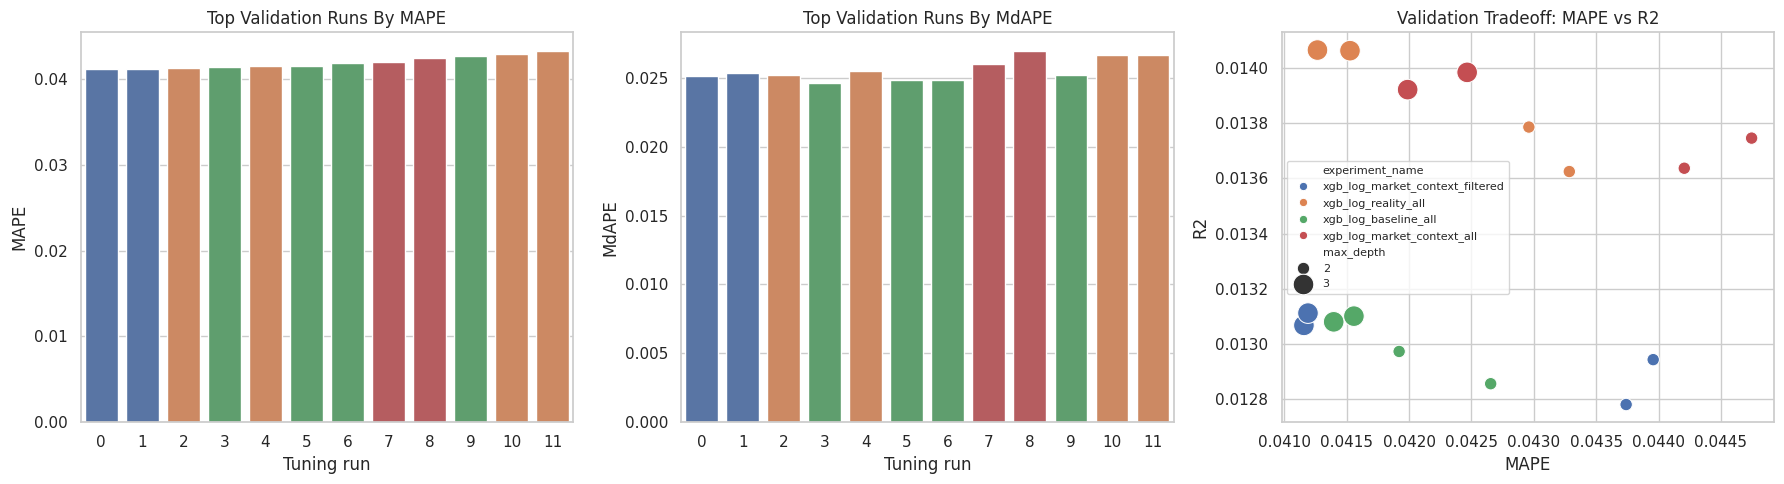

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_tuning = tuning_results_df.head(12).copy()
sns.barplot(
    data=top_tuning, x=top_tuning.index, y="MAPE", hue="experiment_name", ax=axes[0]
)
axes[0].set_title("Top Validation Runs By MAPE")
axes[0].set_xlabel("Tuning run")

sns.barplot(
    data=top_tuning, x=top_tuning.index, y="MdAPE", hue="experiment_name", ax=axes[1]
)
axes[1].set_title("Top Validation Runs By MdAPE")
axes[1].set_xlabel("Tuning run")

sns.scatterplot(
    data=tuning_results_df,
    x="MAPE",
    y="R2",
    hue="experiment_name",
    size="max_depth",
    sizes=(80, 220),
    ax=axes[2],
)
axes[2].set_title("Validation Tradeoff: MAPE vs R2")

for ax in axes[:2]:
    ax.legend_.remove()
axes[2].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

## Final Test Evaluation

For each XGBoost experiment type, I take the best validation configuration, retrain it on the full June 2025 through April 2026 training window, and evaluate once on the unchanged May 2026 test month.

In [11]:
best_by_experiment = (
    tuning_results_df.sort_values(
        ["predictions_over_50m", "MAPE", "MdAPE", "R2"],
        ascending=[True, True, True, False],
    )
    .groupby("experiment_name", as_index=False)
    .first()
)

final_rows = [{"model_name": "LinearRegression", **linear_metrics}]
final_predictions = {
    "LinearRegression": linear_test_preds,
}
final_models = {}

for _, row in best_by_experiment.iterrows():
    spec = next(
        item
        for item in experiment_specs
        if item["experiment_name"] == row["experiment_name"]
    )
    final_train_source = train_df.copy()
    if spec["filter_train"]:
        final_train_source = apply_training_filter(final_train_source)

    final_train_ready, final_test_ready, feature_cols = prepare_experiment_frames(
        final_train_source, test_df, spec["feature_set"]
    )

    params = {
        "max_depth": int(row["max_depth"]),
        "learning_rate": float(row["learning_rate"]),
        "n_estimators": int(row["n_estimators"]),
        "min_child_weight": int(row["min_child_weight"]),
    }

    model, test_preds = train_predict_xgb_log(
        final_train_ready, final_test_ready, feature_cols, params
    )
    metrics = evaluate_predictions(final_test_ready[target_col], test_preds)
    sanity_checks = {
        "min_prediction": test_preds.min(),
        "max_prediction": test_preds.max(),
        "predictions_over_50m": int((test_preds > 50000000).sum()),
    }

    model_name = row["experiment_name"]
    final_rows.append(
        {
            "model_name": model_name,
            "feature_set": spec["feature_set"],
            "filtered_training": spec["filter_train"],
            "feature_count": len(feature_cols),
            "train_rows": len(final_train_ready),
            **params,
            **metrics,
            **sanity_checks,
        }
    )
    final_predictions[model_name] = test_preds
    final_models[model_name] = model

final_results_df = (
    pd.DataFrame(final_rows)
    .sort_values(["R2", "MAPE"], ascending=[False, True])
    .reset_index(drop=True)
)

display(final_results_df)

best_advanced_name = final_results_df.loc[
    final_results_df["model_name"] != "LinearRegression", "model_name"
].iloc[0]
best_overall_name = final_results_df.loc[0, "model_name"]
print(f"Best advanced model: {best_advanced_name}")
print(f"Best overall model: {best_overall_name}")

,model_name,MAE,RMSE,R2,MAPE,MdAPE,feature_set,filtered_training,feature_count,train_rows,max_depth,learning_rate,n_estimators,min_child_weight,min_prediction,max_prediction,predictions_over_50m
0,xgb_log_reality_all,74895.4945,1013074.7035,0.6347,0.0726,0.0253,reality,False,23.0000,118292.0000,3.0000,0.0300,600.0000,15.0000,70148.0547,30188248.0000,0.0000
1,xgb_log_market_context_all,74595.5981,1013250.0030,0.6345,0.0718,0.0249,market_context,False,28.0000,118292.0000,3.0000,0.0300,600.0000,15.0000,70184.0625,30348804.0000,0.0000
2,LinearRegression,198948.9216,1014590.5986,0.6336,0.2456,0.1014,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,xgb_log_market_context_filtered,75860.1949,1033899.5772,0.6195,0.0731,0.0241,market_context,True,28.0000,118063.0000,3.0000,0.0300,600.0000,15.0000,108847.8359,19778122.0000,0.0000
4,xgb_log_baseline_all,81179.8633,1051614.0375,0.6063,0.0723,0.0245,baseline,False,13.0000,118292.0000,3.0000,0.0500,450.0000,25.0000,90702.0391,31946142.0000,0.0000


Best advanced model: xgb_log_reality_all
Best overall model: xgb_log_reality_all


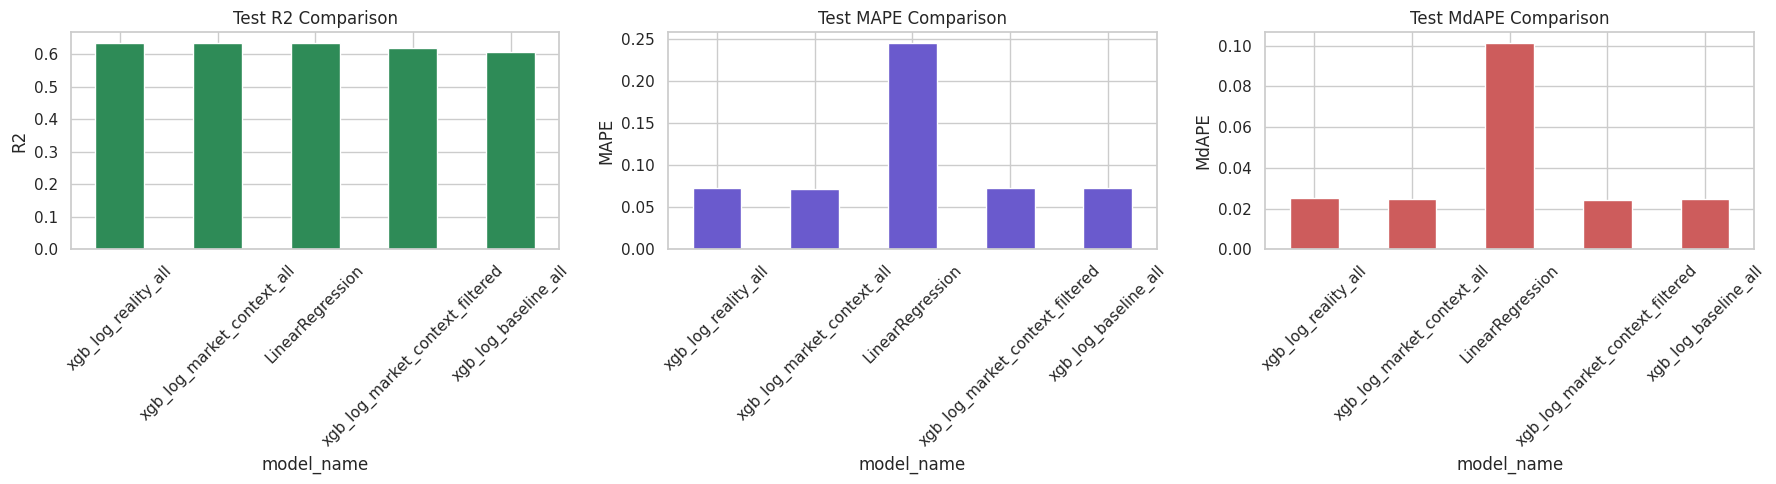

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

final_results_df.plot(
    x="model_name", y="R2", kind="bar", legend=False, ax=axes[0], color="seagreen"
)
axes[0].set_title("Test R2 Comparison")
axes[0].set_ylabel("R2")

final_results_df.plot(
    x="model_name", y="MAPE", kind="bar", legend=False, ax=axes[1], color="slateblue"
)
axes[1].set_title("Test MAPE Comparison")
axes[1].set_ylabel("MAPE")

final_results_df.plot(
    x="model_name", y="MdAPE", kind="bar", legend=False, ax=axes[2], color="indianred"
)
axes[2].set_title("Test MdAPE Comparison")
axes[2].set_ylabel("MdAPE")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Prediction Diagnostics

These plots show how the best advanced model behaves on the test month. They are useful for explaining whether the model is stable, where it overpredicts or underpredicts, and whether extreme homes are still driving errors.

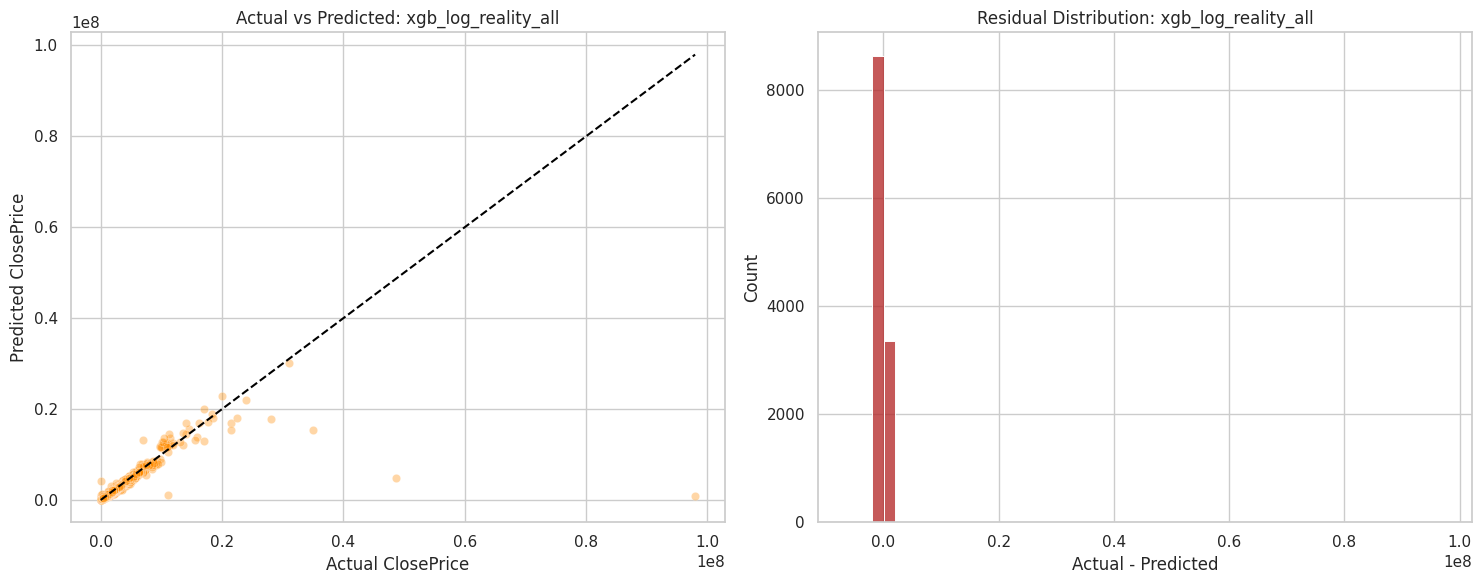

In [13]:
best_advanced_preds = final_predictions[best_advanced_name]
prediction_df = pd.DataFrame(
    {
        "actual": test_df[target_col].values,
        "linear_predicted": linear_test_preds,
        "best_advanced_predicted": best_advanced_preds,
    }
)
prediction_df["linear_residual"] = (
    prediction_df["actual"] - prediction_df["linear_predicted"]
)
prediction_df["advanced_residual"] = (
    prediction_df["actual"] - prediction_df["best_advanced_predicted"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=prediction_df,
    x="actual",
    y="best_advanced_predicted",
    alpha=0.35,
    ax=axes[0],
    color="darkorange",
)
line_min = min(
    prediction_df["actual"].min(), prediction_df["best_advanced_predicted"].min()
)
line_max = max(
    prediction_df["actual"].max(), prediction_df["best_advanced_predicted"].max()
)
axes[0].plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
axes[0].set_title(f"Actual vs Predicted: {best_advanced_name}")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")

sns.histplot(prediction_df["advanced_residual"], bins=50, ax=axes[1], color="firebrick")
axes[1].set_title(f"Residual Distribution: {best_advanced_name}")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

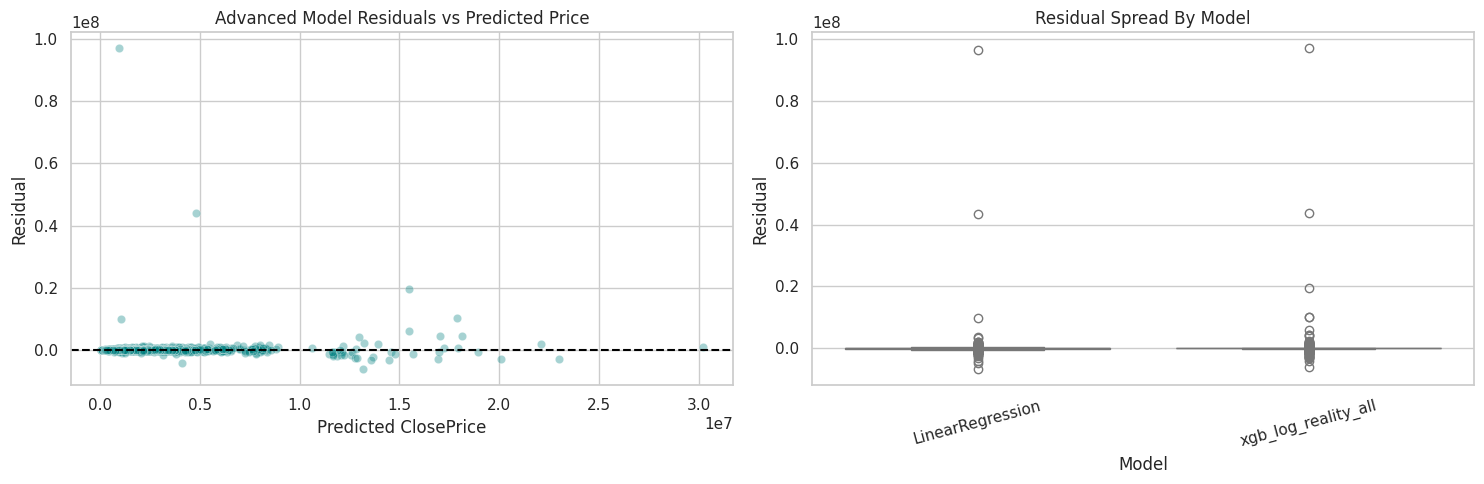

In [14]:
residual_long = prediction_df[["actual", "linear_residual", "advanced_residual"]].melt(
    id_vars="actual",
    value_vars=["linear_residual", "advanced_residual"],
    var_name="model",
    value_name="residual",
)
residual_long["model"] = residual_long["model"].replace(
    {"linear_residual": "LinearRegression", "advanced_residual": best_advanced_name}
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=prediction_df,
    x="best_advanced_predicted",
    y="advanced_residual",
    alpha=0.35,
    ax=axes[0],
    color="teal",
)
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Advanced Model Residuals vs Predicted Price")
axes[0].set_xlabel("Predicted ClosePrice")
axes[0].set_ylabel("Residual")

sns.boxplot(
    data=residual_long, x="model", y="residual", ax=axes[1], color="lightsteelblue"
)
axes[1].set_title("Residual Spread By Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Residual")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## Error By Price Segment

This view is important for real estate modeling because one overall metric can hide where the model actually works. Earlier notebooks showed that unusual low-price sales and ultra-luxury homes behave differently from the mainstream market.

,price_segment,row_count,linear_mape,advanced_mape,linear_mdape,advanced_mdape
0,<$300k,279,2.7172,1.5137,0.5793,0.0531
1,$300k-$500k,1419,0.3335,0.0361,0.1885,0.0220
2,$500k-$1M,4897,0.2188,0.0319,0.1222,0.0215
3,$1M-$3M,4686,0.1247,0.0418,0.0711,0.0282
4,$3M+,740,0.0885,0.0634,0.0669,0.0404


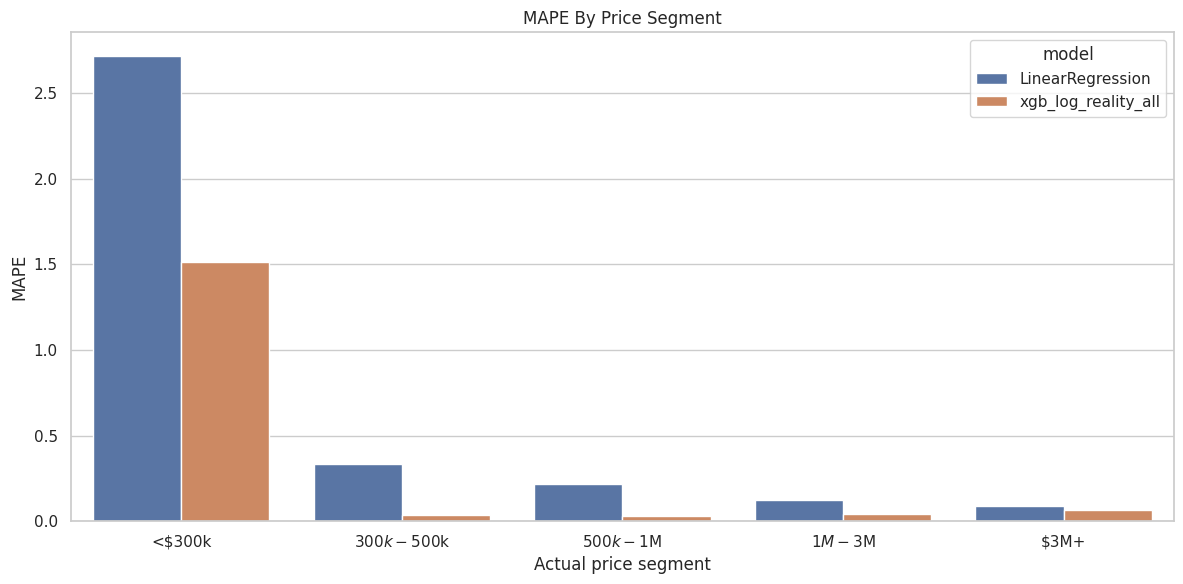

In [15]:
segment_df = prediction_df.copy()
segment_df["price_segment"] = pd.cut(
    segment_df["actual"],
    bins=[0, 300000, 500000, 1000000, 3000000, np.inf],
    labels=["<$300k", "$300k-$500k", "$500k-$1M", "$1M-$3M", "$3M+"],
)
segment_df["linear_ape"] = (
    segment_df["actual"] - segment_df["linear_predicted"]
).abs() / segment_df["actual"]
segment_df["advanced_ape"] = (
    segment_df["actual"] - segment_df["best_advanced_predicted"]
).abs() / segment_df["actual"]

segment_summary = (
    segment_df.groupby("price_segment", observed=True)
    .agg(
        row_count=("actual", "size"),
        linear_mape=("linear_ape", "mean"),
        advanced_mape=("advanced_ape", "mean"),
        linear_mdape=("linear_ape", "median"),
        advanced_mdape=("advanced_ape", "median"),
    )
    .reset_index()
)

display(segment_summary)

segment_plot = segment_summary.melt(
    id_vars=["price_segment", "row_count"],
    value_vars=["linear_mape", "advanced_mape"],
    var_name="model",
    value_name="MAPE",
)
segment_plot["model"] = segment_plot["model"].replace(
    {"linear_mape": "LinearRegression", "advanced_mape": best_advanced_name}
)

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_plot, x="price_segment", y="MAPE", hue="model")
plt.title("MAPE By Price Segment")
plt.xlabel("Actual price segment")
plt.ylabel("MAPE")
plt.tight_layout()
plt.show()

## Prediction Sanity Checks

The first XGBoost attempt produced unrealistic predictions, so this table checks whether the final advanced models still create extreme prediction values.

The refreshed results look much healthier. The Linear Regression baseline still creates 2 negative predictions, while all final XGBoost versions produce no negative predictions and no predictions above `$50M`. This is one reason the log-target XGBoost setup is more realistic for a pricing workflow.

In [16]:
sanity_rows = []
for model_name, preds in final_predictions.items():
    sanity_rows.append(
        {
            "model_name": model_name,
            "min_prediction": preds.min(),
            "max_prediction": preds.max(),
            "predictions_under_0": int((preds < 0).sum()),
            "predictions_over_50m": int((preds > 50000000).sum()),
        }
    )

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

,model_name,min_prediction,max_prediction,predictions_under_0,predictions_over_50m
0,LinearRegression,-57667.4505,32606342.2777,2,0
1,xgb_log_baseline_all,90702.0391,31946142.0000,0,0
2,xgb_log_market_context_all,70184.0625,30348804.0000,0,0
3,xgb_log_market_context_filtered,108847.8359,19778122.0000,0,0
4,xgb_log_reality_all,70148.0547,30188248.0000,0,0


## Feature Importance

This chart shows which processed features the best advanced model relied on most.

,feature,importance
0,num__ListPrice,0.4419
42,cat__CountyOrParish_Riverside,0.1696
12,num__list_price_per_sqft,0.1057
10,num__log_living_area,0.1038
45,cat__CountyOrParish_San Bernardino,0.0569
1,num__LivingArea,0.0567
3,num__BathroomsTotalInteger,0.0326
9,num__property_age,0.0082
7,num__Longitude,0.0071
21,cat__CountyOrParish_Alameda,0.0019


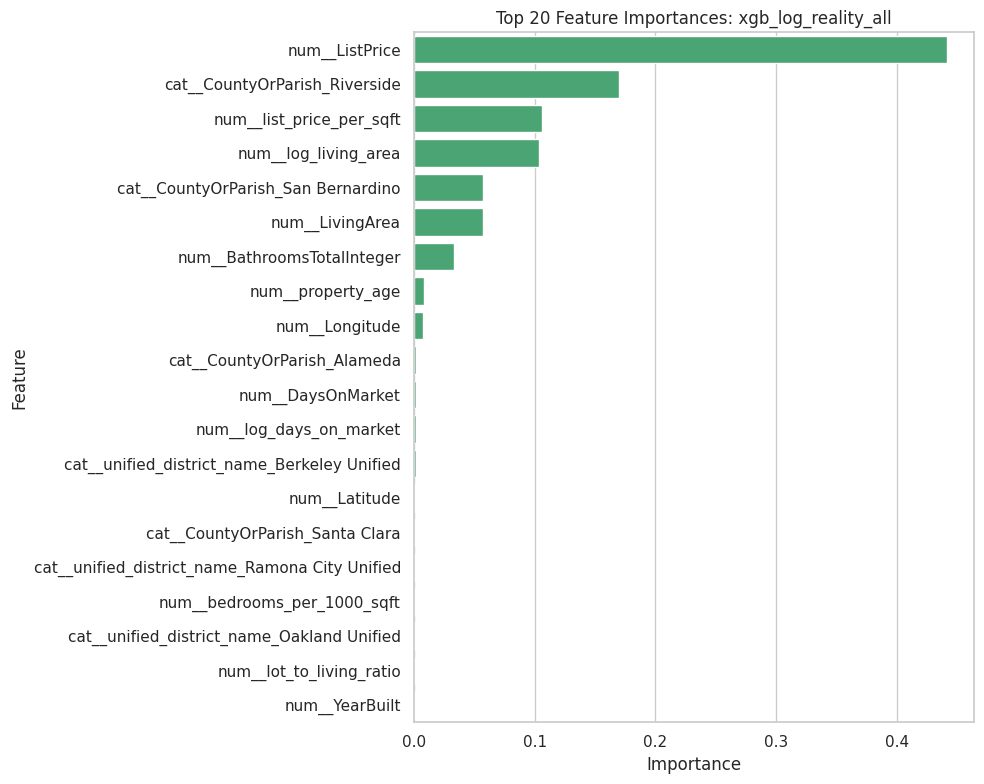

In [17]:
best_model = final_models[best_advanced_name]
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20), x="importance", y="feature", color="mediumseagreen"
)
plt.title(f"Top 20 Feature Importances: {best_advanced_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [18]:
advanced_results_path = output_dir / "week7_advanced_model_results.csv"
tuning_results_path = output_dir / "week7_xgboost_tuning_results.csv"
predictions_path = output_dir / "week7_best_advanced_predictions.csv"
segment_results_path = output_dir / "week7_price_segment_results.csv"
sanity_results_path = output_dir / "week7_prediction_sanity_checks.csv"
importance_path = output_dir / "week7_feature_importance.csv"

final_results_df.to_csv(advanced_results_path, index=False)
tuning_results_df.to_csv(tuning_results_path, index=False)
prediction_df.to_csv(predictions_path, index=False)
segment_summary.to_csv(segment_results_path, index=False)
sanity_df.to_csv(sanity_results_path, index=False)
importance_df.to_csv(importance_path, index=False)

print(f"Saved final model results to {advanced_results_path}")
print(f"Saved tuning results to {tuning_results_path}")
print(f"Saved predictions to {predictions_path}")
print(f"Saved price-segment results to {segment_results_path}")
print(f"Saved prediction sanity checks to {sanity_results_path}")
print(f"Saved feature importance to {importance_path}")

Saved final model results to ../outputs/week7_advanced_model_results.csv
Saved tuning results to ../outputs/week7_xgboost_tuning_results.csv
Saved predictions to ../outputs/week7_best_advanced_predictions.csv
Saved price-segment results to ../outputs/week7_price_segment_results.csv
Saved prediction sanity checks to ../outputs/week7_prediction_sanity_checks.csv
Saved feature importance to ../outputs/week7_feature_importance.csv


## Final Week 7 Conclusion

Week 7 is complete after tuning and evaluating several XGBoost versions on the unchanged May 2026 test month.

The best advanced model is very close to the linear baseline on `R²`, but much stronger on percentage-error metrics. The top XGBoost versions score around `R² = 0.6345`, while Linear Regression scores `R² = 0.6336`. The bigger difference is practical error: `xgb_log_market_context_all` has `MAPE = 7.18%` and `MdAPE = 2.49%`, compared with Linear Regression at `MAPE = 24.56%` and `MdAPE = 10.14%`.

This means XGBoost does not dramatically improve variance explained, but it gives much more realistic percentage errors for most homes. The price-band analysis supports this: XGBoost improves MAPE across every price band, especially mainstream ranges such as `$300k-$500k`, `$500k-$1M`, and `$1M-$3M`. The lowest price band remains difficult because it likely contains unusual or non-standard transactions.

Based on these results, I would keep Linear Regression as the simple baseline and use `xgb_log_market_context_all` or `xgb_log_reality_all` as the strongest advanced-model candidate going forward.